In [1]:
import matplotlib.pyplot as plt


from sklearn.datasets import make_swiss_roll
from sklearn.neighbors import NearestNeighbors
from sklearn.decomposition import PCA
from collections import deque

In [2]:
from utils import *

# Manifold Sculpting

In [3]:
def Manifold_Sculpting(X, k=5, pca_dim=2, D_preserved=2, sigma=0.99, n_iter=100):

    # Step 1 : find k nearest neighbours for each point - start with k=5
    nbrs = NearestNeighbors(n_neighbors=k+1).fit(X)
    _, indices = nbrs.kneighbors(X)

    # Step 2 : compute the original set of relationships
    n = X.shape[0]
    original_angle, original_dist, original_average_dist = compute_relationships(X, k, indices, n)
    eta = original_average_dist

    # Step 3 : Optionally align axes using PCA
    if pca_dim > 0:
        X = PCA(n_components = pca_dim).fit_transform(X)
    
    # Step 4 : Reconstruct the set of relationships
    for counter in range(n_iter):  
        print(counter, "\n")  
        X[:, D_preserved:] *= sigma             
        _, new_av_dist = compute_distances(X, k, indices, n)
        # Scale up the fist dimesions while preserving the global average distance
        while new_av_dist < original_average_dist:
                        X[:, :D_preserved] /= sigma
                        _, new_av_dist = compute_distances(X, k, indices, n)

        #print("Average distance: ", new_av_dist, "\n")

        adjusted = set()    # set of adjusted points
        
        # Start with a randomly selected point
        start_point = np.random.randint(n)
        queue = deque([start_point])
        step = 0

        while queue:
            i = queue.popleft()
            if i not in adjusted:
                    s = adjust_point(X, k, indices, n, X[i],i, eta, original_dist, original_angle, original_average_dist, D_preserved)
                    step += s
                    adjusted.add(i)      # mark i as adjusted
            #print("Adjusted: ", adjusted, "\n")
                
            for j in indices[i, 1:]:
                    if j not in adjusted and j not in queue:
                            queue.append(j)
            #print("Queue: ", queue, "\n")

        eta *= 1.1 if step >= n else 0.9

    
    # Step 5 : Drop the last unused dimensions
    X = X[:, :D_preserved]

    return X
    
    

# Swiss role

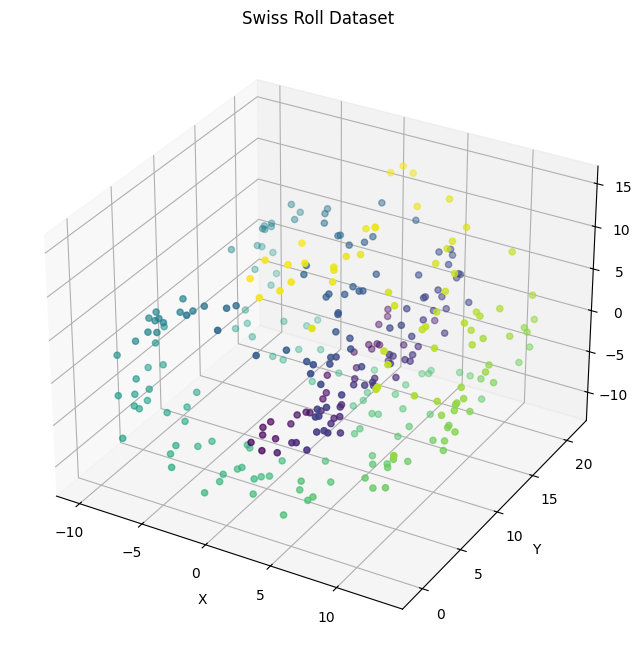

In [4]:
# Generate Swiss roll dataset
n = 300
noise = 0.5
X, color = make_swiss_roll(n_samples= n, hole=True , noise= noise, random_state=42)

# Plot the Swiss roll
fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')
ax.scatter(X[:, 0], X[:, 1],X[:, 2], c=color, cmap=plt.cm.viridis)

ax.set_title('Swiss Roll Dataset')
ax.set_xlabel('X')
ax.set_ylabel('Y')
ax.set_zlabel('Z')

plt.show()


In [6]:
X = Manifold_Sculpting(X, n_iter=10)

c:\Users\maria\Desktop\UniTS\Unsupervised learning\unsupervised_learning\utils.py:20: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = (dot_product / (np.linalg.norm(v1) * np.linalg.norm(v2)))
c:\Users\maria\Desktop\UniTS\Unsupervised learning\unsupervised_learning\utils.py:21: RuntimeWarning: invalid value encountered in arccos
  angle = np.arccos(cos_angle)


0 



c:\Users\maria\Desktop\UniTS\Unsupervised learning\unsupervised_learning\utils.py:20: RuntimeWarning: invalid value encountered in scalar divide
  cos_angle = (dot_product / (np.linalg.norm(v1) * np.linalg.norm(v2)))
c:\Users\maria\Desktop\UniTS\Unsupervised learning\unsupervised_learning\utils.py:21: RuntimeWarning: invalid value encountered in arccos
  angle = np.arccos(cos_angle)


1 

2 

3 

4 

5 

6 

7 

8 

9 



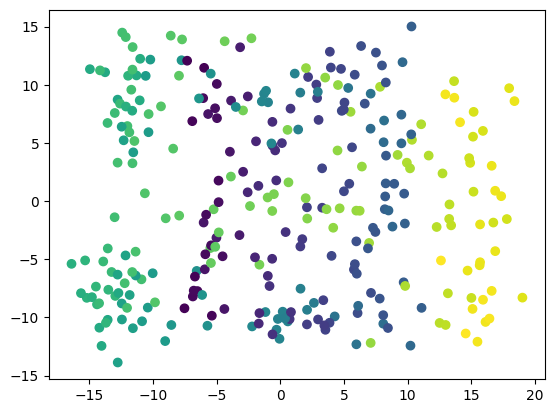

In [7]:
# plot the final result
fig = plt.figure()
ax = fig.add_subplot(111)
ax.scatter(X[:, 0], X[:, 1], c=color, cmap=plt.cm.viridis)